# Multi Objective Optimization

In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

In [5]:
import os
import yaml
import pandas as pd
import seaborn as sns
import numpy as np
from src.policy_regulation import PolicyRegulator
import src.utils as utils
from src.policies.custom_policies import adaptive_quota, hard_ecofair_incentives_policy, smooth_ecofair_incentives_policy
import optuna
import matplotlib.pyplot as plt

/mnt/c/users/oluwa/OneDrive_V2/OneDrive/Competitions/Hackathon-Water-Scarcity/src/policy_regulation.py:74: ExperimentalWarning:

NSGAIIISampler is experimental (supported from v3.2.0). The interface can change in the future.

/mnt/c/users/oluwa/OneDrive_V2/OneDrive/Competitions/Hackathon-Water-Scarcity/src/policy_regulation.py:75: ExperimentalWarning:

QMCSampler is experimental (supported from v3.0.0). The interface can change in the future.



## Understand Actors

In [ ]:
actors_yml = os.listdir('./parameters/actors')

In [ ]:
actors = []
columns = None
for actor in actors_yml:
    yaml_path = f"./parameters/actors/{actor}"
    with open(yaml_path, 'r') as file:
        tmp = yaml.safe_load(file)
        actors.append(tmp['parameters'])
        if columns == None:
            columns = list(tmp.keys())

In [6]:
actors_df = pd.DataFrame(actors)#, columns = columns)
actors_df.head()

,type,name,demands,storage_capa,initial_storage,forecast_bias,forecast_uncertainty,ict,lr_factor,values,ecol_impact,priority,reput_cost,baseline_income_factor
0,Agriculture,Agriculture pos. bias,10.0,2.0,2.0,0.5,0.00,0.5,0.005,1.0,1.0,1.0,0.0,1.0
1,Agriculture,Agriculture neg. bias,10.0,2.0,2.0,-0.5,0.00,0.5,0.005,1.0,1.0,1.0,0.0,1.0
2,Agriculture,Agriculture bias + var.,10.0,2.0,2.0,0.5,0.50,0.5,0.005,1.0,1.0,1.0,0.0,1.0
3,Agriculture,Agriculture small var.,10.0,2.0,2.0,0.0,0.25,0.5,0.005,1.0,1.0,1.0,0.0,1.0
4,Agriculture,Agriculture strong var.,10.0,2.0,2.0,0.0,0.50,0.5,0.005,1.0,1.0,1.0,0.0,1.0


In [7]:
actors_buffer = actors_df.groupby(['type', 'priority']
                                 )[['demands', 'storage_capa']].mean(
                                 ).apply(lambda x: x.storage_capa / x.demands, axis = 1
                                        ).reset_index().set_index('type'
                                                                 ).rename(columns = {0:'buffer'})

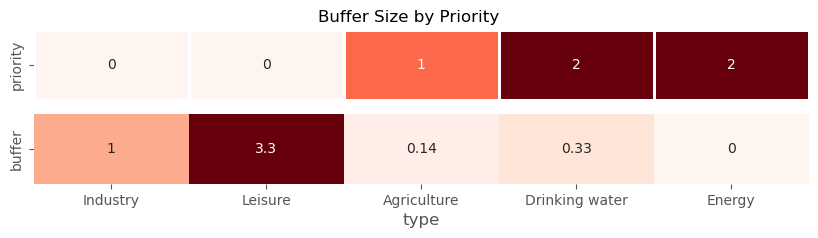

In [8]:
fig, ax = plt.subplots(2, 1, figsize = (10, 2))
tmp = actors_buffer[['priority', 'buffer']].sort_values('priority')
sns.heatmap(tmp[['priority']].T, annot = True, ax = ax[0], cbar = False, cmap = 'Reds', linewidth = 1.0)
sns.heatmap(tmp[['buffer']].T, cmap = 'Reds', annot = True, ax = ax[1], cbar = False)
ax[0].set_xticks([])
ax[0].set_xlabel('')
# plt.tight_layout()
fig.suptitle('Buffer Size by Priority', fontsize = 12)
plt.savefig('./assets/images/actors_buffer.png', dpi = 300, bbox_inches = 'tight')

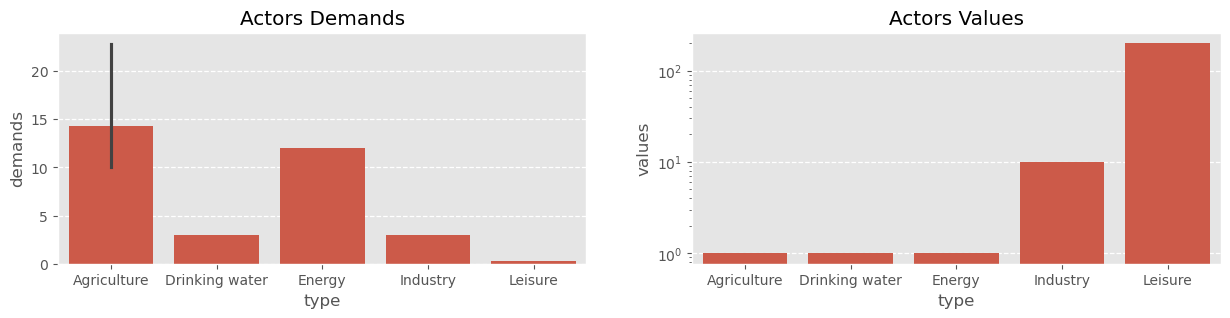

In [9]:
fig, ax = plt.subplots(1, 2, figsize = (15, 3))
sns.barplot(actors_df, x = 'type', y = 'demands', ax = ax[0])
ax[0].set_title('Actors Demands')
sns.barplot(actors_df, x = 'type', y = 'values', ax = ax[1])
ax[1].set_title('Actors Values')
ax[1].set_yscale('log')
plt.savefig('./assets/images/actors_demand_values.png', dpi = 300, bbox_inches = 'tight')

## Define parmeters

In [ ]:
quota_parameters = dict(
    rate = ['float', 1.0, 3.0], #1.2
    priority_effect = ['float', 0.01, 5.0], #2.35
    crisis_rate = ['float', 1.0, 5.0] #3.0
)

incentives_parameters = dict(
    max_subvention_weight = ['float', -10.0, -0.00], #-1.0
    max_fine_weight = ['float', 0.0, 5.0], #0.05
    policy_rate = ['float', 1.0, 20.0], #10.0
    crisis_sensitivity = ['float', 1.0, 5.0], #2.0
    equity_factor = ['float', 1.0, 50.0], #10.0,
    subsidy_fine_ratio = ['float', 0.5, 2.0],
    alpha = ['float', 0.0, 1.0], #0.5   
)

# full simulation parameters
simulation_parameters = dict(
    turns = 700,
    iterations = 5,
    verbose = 0,
    max_workers = 16
)

# minimal simulation parameters
simulation_parameters_minimal= dict(
    turns = 700, 
    iterations = 5,
    exploration_biases = [0.0, 0.5, -0.5], 
    exploration_uncertainties = [0.0, 0.5],
    verbose = 0,
    max_workers = 16
)

# minified simulation parameters
simulation_parameters_minified = dict(
    turns = 700, 
    iterations = 5,
    exploration_biases = [-0.5, 0.5], 
    exploration_uncertainties = [0.0],
    scenarios = ['0.yml', '1.yml'], 
    verbose = 0,
    max_workers = 16
)

## Hard Incentives Policy Optimization

In [11]:
%%time
if True:
    pol_reg = PolicyRegulator(
        quota_policy = adaptive_quota,
        incentives_policy = hard_ecofair_incentives_policy,
        quota_params = quota_parameters,
        incentives_params = incentives_parameters,
        simulation_params = simulation_parameters,
        name = 'multi-objective',
        sampler = optuna.samplers.NSGAIISampler(population_size = 15, seed = 42) #'nsga_2',
    )
    
    
    pol_reg.optimize_objective(n_trials = 60, timeout = None) #timeout after 3 hours

[I 2025-05-25 02:50:18,713] A new study created in memory with name: multi-objective


Starting optimization...


[I 2025-05-25 02:58:18,012] Trial 0 finished with values: [2.091652842658645, -0.3037975121684481] and parameters: {'rate': 1.749080237694725, 'priority_effect': 4.754064388985482, 'crisis_rate': 3.9279757672456204, 'max_subvention_weight': -4.013415158029634, 'max_fine_weight': 0.7800932022121826, 'policy_rate': 3.96389588638785, 'crisis_sensitivity': 1.2323344486727978, 'equity_factor': 43.44263114297183, 'subsidy_fine_ratio': 1.4016725176148133, 'alpha': 0.7080725777960455}.
[I 2025-05-25 03:06:21,929] Trial 1 finished with values: [2.024428121540049, -0.24349039614601276] and parameters: {'rate': 1.041168988591605, 'priority_effect': 4.849850162288352, 'crisis_rate': 4.329770563201687, 'max_subvention_weight': -7.876608893217238, 'max_fine_weight': 0.9091248360355031, 'policy_rate': 4.484685687215243, 'crisis_sensitivity': 2.216968971838151, 'equity_factor': 26.713065149979656, 'subsidy_fine_ratio': 1.1479175279631737, 'alpha': 0.2912291401980419}.
[I 2025-05-25 03:13:49,691] Trial

Optimization complete
CPU times: user 20.7 s, sys: 9.89 s, total: 30.6 s
Wall time: 7h 31min 27s


In [153]:
save_policy_name = './saved_polices/ecofair_policies'

/mnt/c/users/oluwa/OneDrive_V2/OneDrive/Competitions/Hackathon-Water-Scarcity/src/policy_regulation.py:74: ExperimentalWarning:

NSGAIIISampler is experimental (supported from v3.2.0). The interface can change in the future.

/mnt/c/users/oluwa/OneDrive_V2/OneDrive/Competitions/Hackathon-Water-Scarcity/src/policy_regulation.py:75: ExperimentalWarning:

QMCSampler is experimental (supported from v3.0.0). The interface can change in the future.



In [154]:
pol_reg.save(save_policy_name)

In [6]:
pol_reg = PolicyRegulator.from_preoptimized('./saved_polices/ecofair_policies')
# TEMP FIX
pol_reg.quota_policy = adaptive_quota
pol_reg.incentives_policy = hard_ecofair_incentives_policy
# quota_policy

/mnt/c/users/oluwa/OneDrive_V2/OneDrive/Competitions/Hackathon-Water-Scarcity/src/policy_regulation.py:239: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored



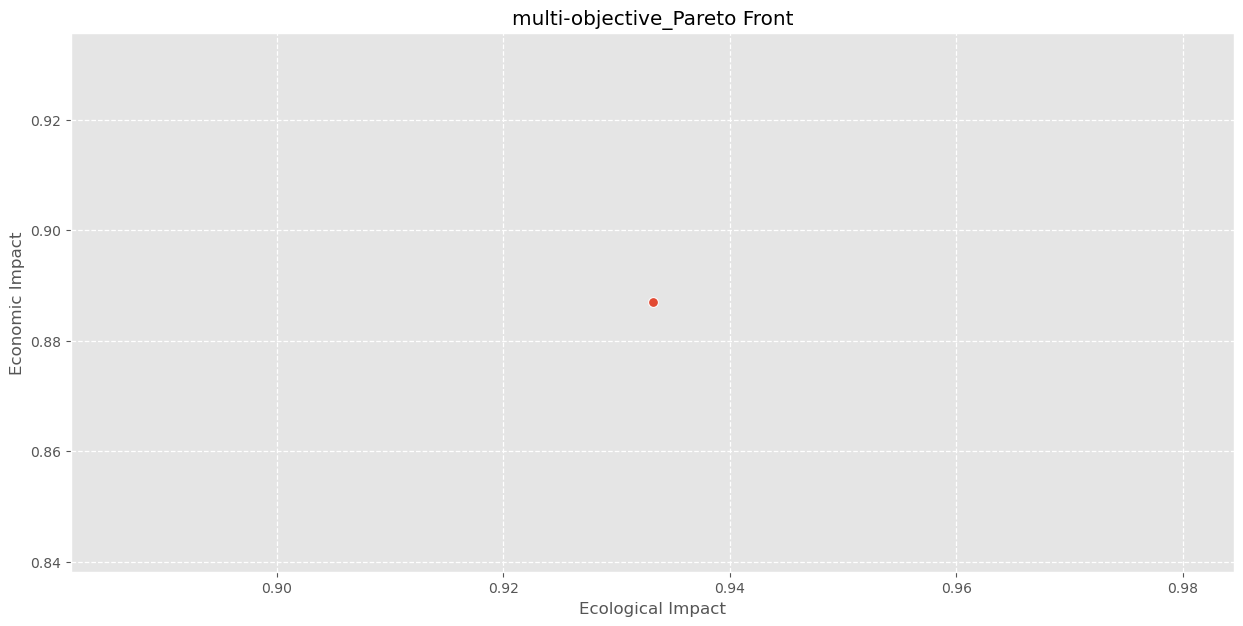

In [159]:
pol_reg.plot_pareto_front(show_dominated = False)

In [25]:
results_df.loc[46]

cooperation          0.463281
satisfaction              1.0
ecological_impact    0.939211
economic_impact      0.840098
satisfied                True
Name: 46, dtype: object

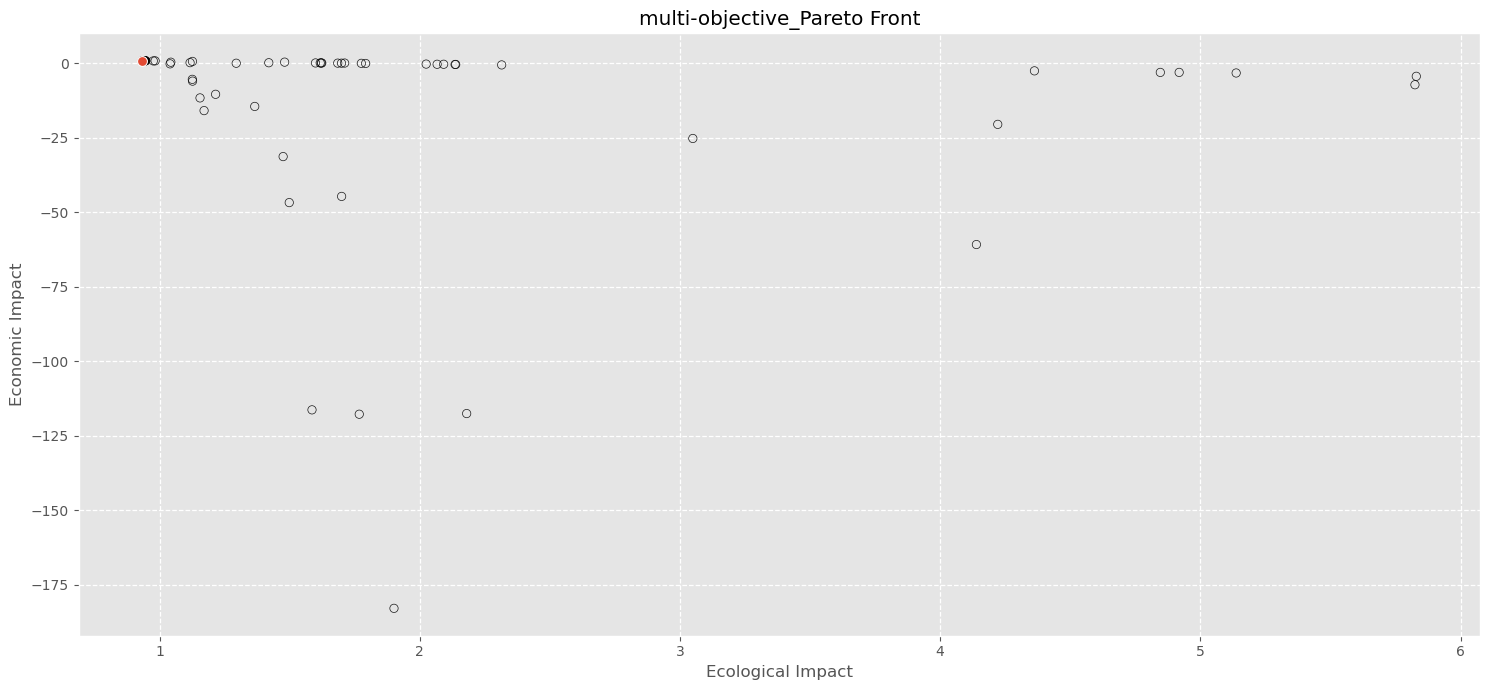

In [15]:
pol_reg.plot_pareto_front(show_dominated = True)
plt.tight_layout()

In [16]:
pol_reg.study.best_trials

[FrozenTrial(number=33, state=1, values=[0.93316611637399, 0.8869350044521288], datetime_start=datetime.datetime(2025, 5, 25, 6, 56, 9, 205961), datetime_complete=datetime.datetime(2025, 5, 25, 7, 3, 33, 418162), params={'rate': 1.2391884918766034, 'priority_effect': 0.8609153771995848, 'crisis_rate': 1.1631005662190557, 'max_subvention_weight': -0.5111446274666669, 'max_fine_weight': 4.828160165372797, 'policy_rate': 1.700851999736123, 'crisis_sensitivity': 3.0909313175279762, 'equity_factor': 5.78593358631281, 'subsidy_fine_ratio': 0.5772181268749841, 'alpha': 0.4401524937396013}, user_attrs={'cooperation': 0.48457738095238095, 'satisfaction': 1.0}, system_attrs={'nsga2:generation': 2}, intermediate_values={}, distributions={'rate': FloatDistribution(high=3.0, log=False, low=1.0, step=None), 'priority_effect': FloatDistribution(high=5.0, log=False, low=0.01, step=None), 'crisis_rate': FloatDistribution(high=5.0, log=False, low=1.0, step=None), 'max_subvention_weight': FloatDistributi

/mnt/c/users/oluwa/OneDrive_V2/OneDrive/Competitions/Hackathon-Water-Scarcity/src/policy_regulation.py:357: ExperimentalWarning:

plot_hypervolume_history is experimental (supported from v3.3.0). The interface can change in the future.



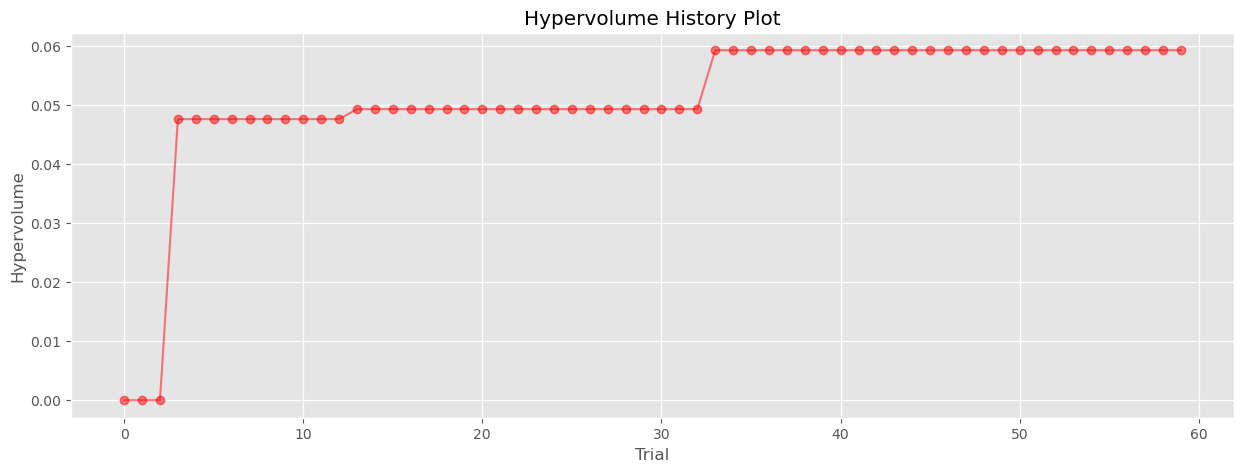

In [31]:
# fig, ax = plt.subplots()
pol_reg.plot_hypervolume(figsize = (15, 5), save_path = './assets/images/hypervolume.png')

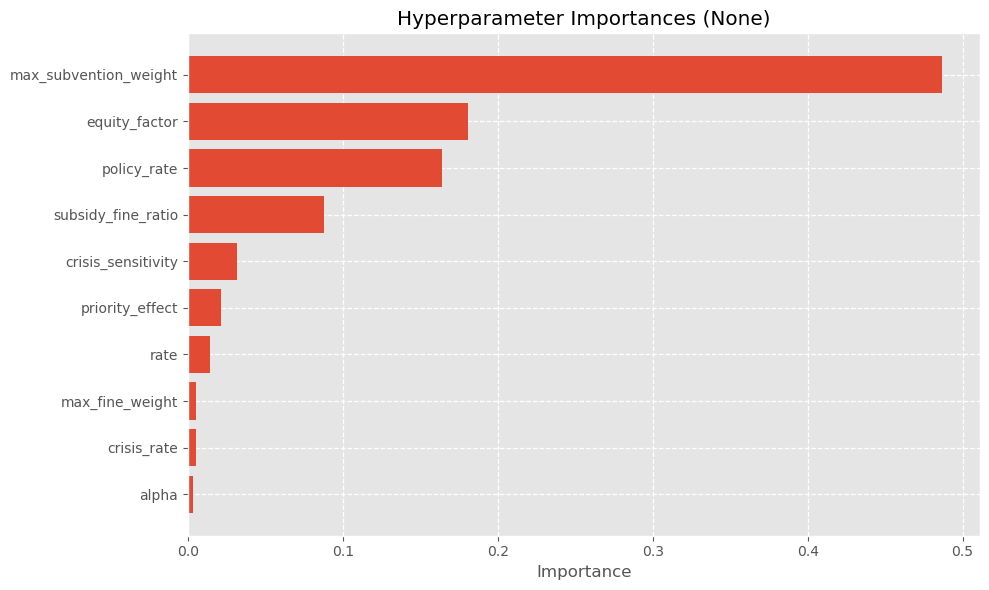

In [7]:
pol_reg.plot_feature_importances(None, target = lambda t: t.values[1], save_path = './assets/images/optimization_hyp_importances_econ.png')
# plt.savefig('./assets/images/optimization_hyp_importances.png', dpi = 300)

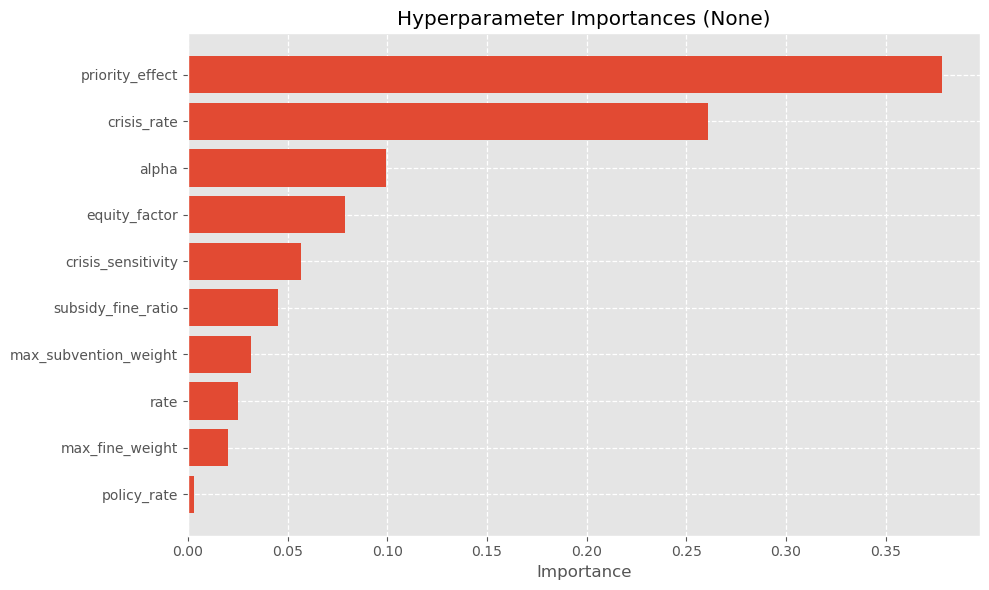

In [8]:
pol_reg.plot_feature_importances(None, target = lambda t: t.values[0], save_path = './assets/images/optimization_hyp_importances_ecol.png')
# plt.savefig('./assets/images/optimization_hyp_importances.png', dpi = 300)

In [39]:
best_trial = pol_reg.find_best_pareto_elbow_gradient(plot = True)
print('Best Values - Ecological_imapct:', best_trial.values[0])
print('Best Values - Economic_imapct:', best_trial.values[1])
# print('Best Values - Satisfaction_Level:', best_trial_50_percentile.values[2])
print('Best Values - Satisfaction_Level:', best_trial.user_attrs)

Only one Pareto-optimal trials found. Returning single solution.
Best Values - Ecological_imapct: 0.93316611637399
Best Values - Economic_imapct: 0.8869350044521288
Best Values - Satisfaction_Level: {'cooperation': 0.48457738095238095, 'satisfaction': 1.0}


In [40]:
best_trial_angle = pol_reg.find_best_pareto_elbow_angle(plot = True)
print('Best Values - Ecological_imapct:', best_trial_angle.values[0])
print('Best Values - Economic_imapct:', best_trial_angle.values[1])
# print('Best Values - Satisfaction_Level:', best_trial_90_percentile.values[2])
print('Best Values - Satisfaction_Level:', best_trial_angle.user_attrs)

Only one Pareto-optimal trials found. Returning single solution.
Best Values - Ecological_imapct: 0.93316611637399
Best Values - Economic_imapct: 0.8869350044521288
Best Values - Satisfaction_Level: {'cooperation': 0.48457738095238095, 'satisfaction': 1.0}


In [41]:
best_trial.params

{'rate': 1.2391884918766034,
 'priority_effect': 0.8609153771995848,
 'crisis_rate': 1.1631005662190557,
 'max_subvention_weight': -0.5111446274666669,
 'max_fine_weight': 4.828160165372797,
 'policy_rate': 1.700851999736123,
 'crisis_sensitivity': 3.0909313175279762,
 'equity_factor': 5.78593358631281,
 'subsidy_fine_ratio': 0.5772181268749841,
 'alpha': 0.4401524937396013}

In [16]:
# get policy function
quota_function, hard_incentives_function = pol_reg.get_best_policy_functions(best_trial.params)

## Policy Behaviour

In [20]:
cooperation = []
satisfaction = []
ecological_impact = []
economic_impact = []
trial_num = []
trial_params = []
for trial in pol_reg.study.trials:
    coop = trial.user_attrs['cooperation']
    sat = trial.user_attrs['satisfaction']
    ecol_impact = trial.values[0]
    econ_impact = trial.values[1]
    penalty = (1 - sat) * 0.5
    ecol_impact -= penalty
    econ_impact += penalty
    cooperation.append(coop)
    satisfaction.append(sat)
    ecological_impact.append(ecol_impact)
    economic_impact.append(econ_impact)
    trial_params.append(trial.params)
results_df = pd.DataFrame(data = {
    # 'trial_id' : trial_num,
    'cooperation': cooperation,
    'satisfaction': satisfaction,
    'ecological_impact': ecological_impact,
    'economic_impact': economic_impact
})
results_df['satisfied'] = (results_df.satisfaction == 1).astype('category')
params_df = pd.DataFrame(trial_params)
params_df['max_subvention_weight'] = params_df.max_subvention_weight.abs()

In [21]:
combined_df = pd.concat([results_df, params_df], axis = 1)
corr_df = combined_df.corr().drop(columns = 'satisfied')

### Objectives Correlation

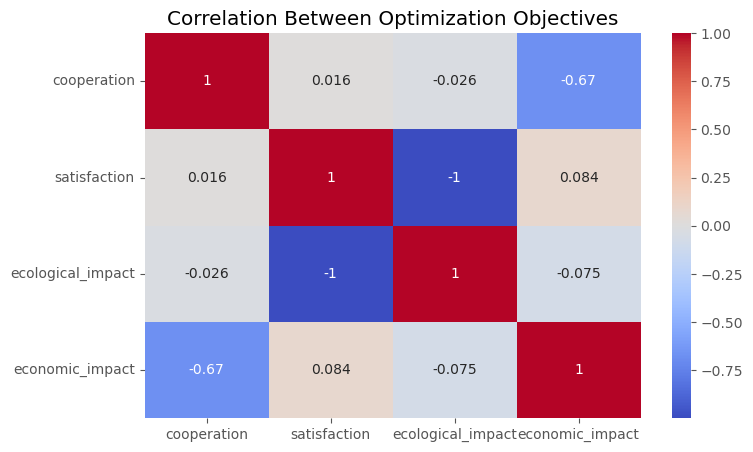

In [30]:
plt.figure(figsize = (8, 5))
sns.heatmap(results_df.drop(columns = 'satisfied').corr(), annot = True, cmap = 'coolwarm')
plt.title('Correlation Between Optimization Objectives');
plt.savefig('./assets/images/objectives_correlation.png', dpi = 300, bbox_inches = 'tight')

### Parameters Correlation

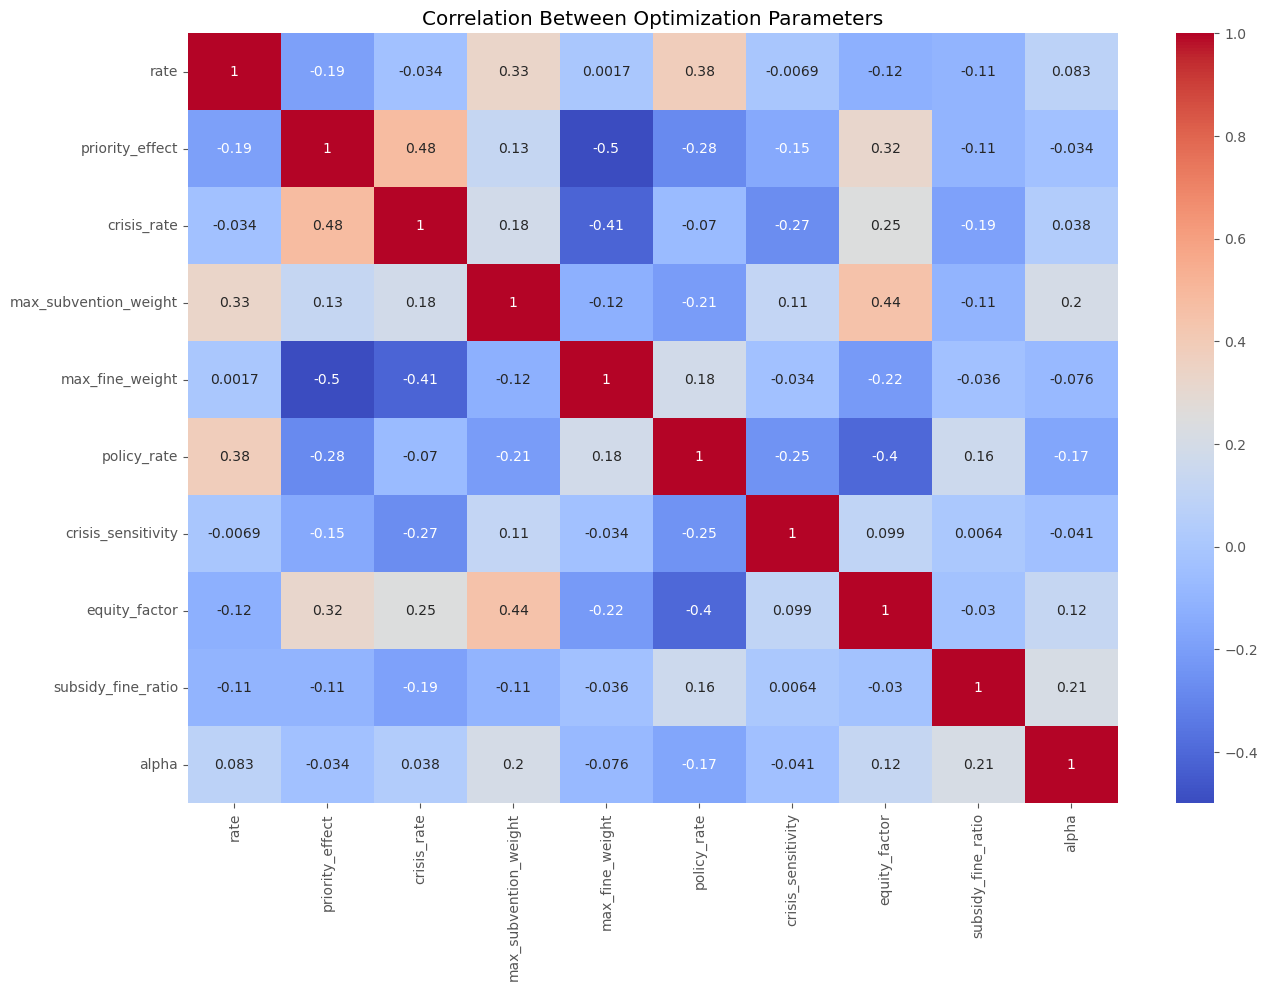

In [50]:
plt.figure(figsize = (15, 10))
sns.heatmap(params_df.corr(), cmap = 'coolwarm', annot = True)
plt.title('Correlation Between Optimization Parameters')
plt.savefig('./assets/images/policy_parameter_correlation.png', dpi = 300, bbox_inches = 'tight')

### Check Priority Effect

In [22]:
priority_ok =  {
    1: "#2E8B57",  # Sea Green - Satisfy priority
    0: "#FF6347",  # Tomato - Do not satisfy priority
}
priority_ok = [ "#FF6347", "#2E8B57"]

### Objectives & Parameters Correlation

In [52]:
os.makedirs('./assets/images', exist_ok = True)

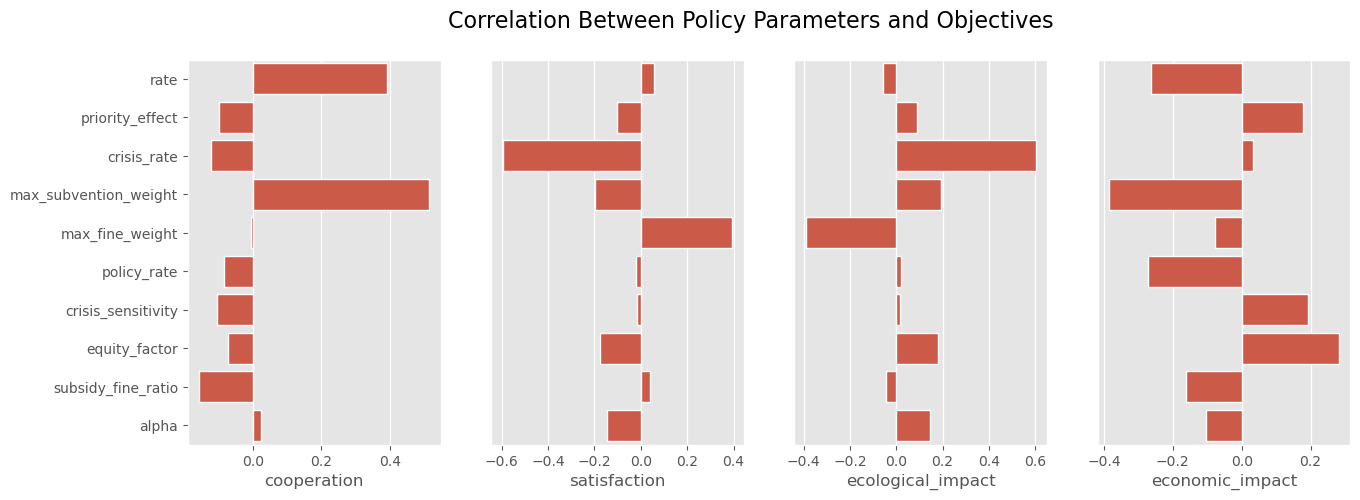

In [53]:
fig, ax = plt.subplots(1, 4, figsize = (15, 5))
sns.barplot(corr_df.cooperation.drop(results_df.columns), orient = 'y', ax = ax[0], edgecolor = 'white', linewidth = 1)
sns.barplot(corr_df.satisfaction.drop(results_df.columns), orient = 'y', ax = ax[1], edgecolor = 'white', linewidth = 1)
ax[1].set_yticks([])
sns.barplot(corr_df.ecological_impact.drop(results_df.columns), orient = 'y', ax = ax[2], edgecolor = 'white', linewidth = 1)
ax[2].set_yticks([])
sns.barplot(corr_df.economic_impact.drop(results_df.columns), orient = 'y', ax = ax[3], edgecolor = 'white', linewidth = 1)
ax[3].set_yticks([])
# plt.tick_params(rotation = 90)
fig.suptitle('Correlation Between Policy Parameters and Objectives', fontsize = 16);
plt.savefig('./assets/images/policy_parameter_effects.png', dpi = 300, bbox_inches = 'tight')

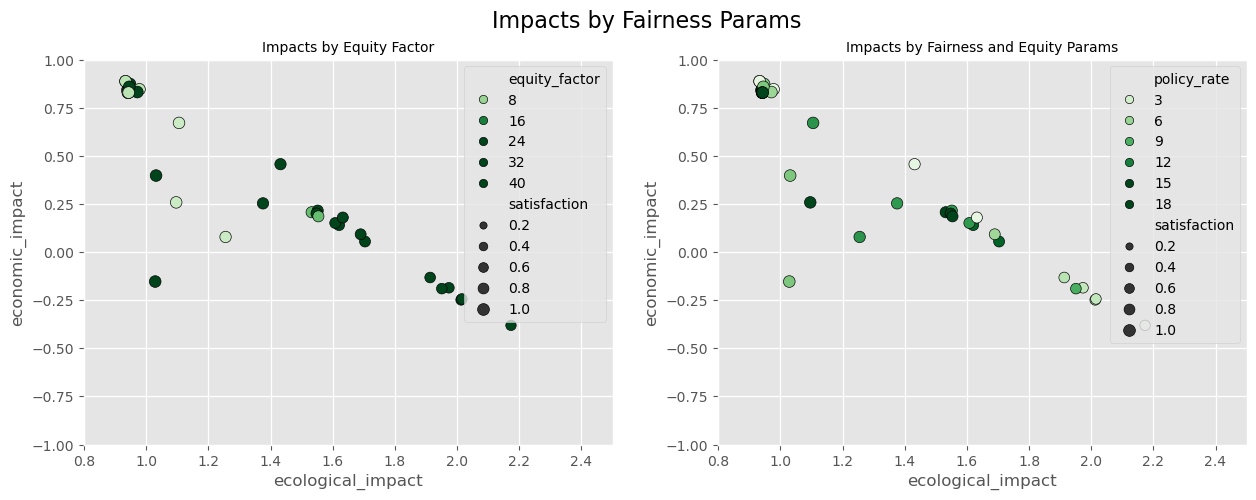

In [37]:
fig, ax = plt.subplots(1, 2, figsize = (15, 5))
sns.scatterplot(combined_df, x = 'ecological_impact', y = 'economic_impact', hue = 'equity_factor', ax = ax[0], hue_norm = (0, 20), edgecolor = 'black', palette =  'Greens', size = 'satisfaction')
sns.scatterplot(combined_df, x = 'ecological_impact', y = 'economic_impact', hue = 'policy_rate', ax = ax[1], hue_norm = (0., 15), edgecolor = 'black', palette = 'Greens', size = 'satisfaction')
ax[0].set_ylim(-1, 1)
ax[0].set_xlim(0.8, 2.5)
ax[0].set_title('Impacts by Equity Factor', fontsize = 10)
ax[1].set_ylim(-1, 1)
ax[1].set_xlim(0.8, 2.5)
ax[1].set_title('Impacts by Fairness and Equity Params', fontsize = 10)
fig.suptitle('Impacts by Fairness Params', fontsize = 16);
plt.savefig('./assets/images/impacts_by_fairness_params.png', dpi = 300, bbox_inches = 'tight')

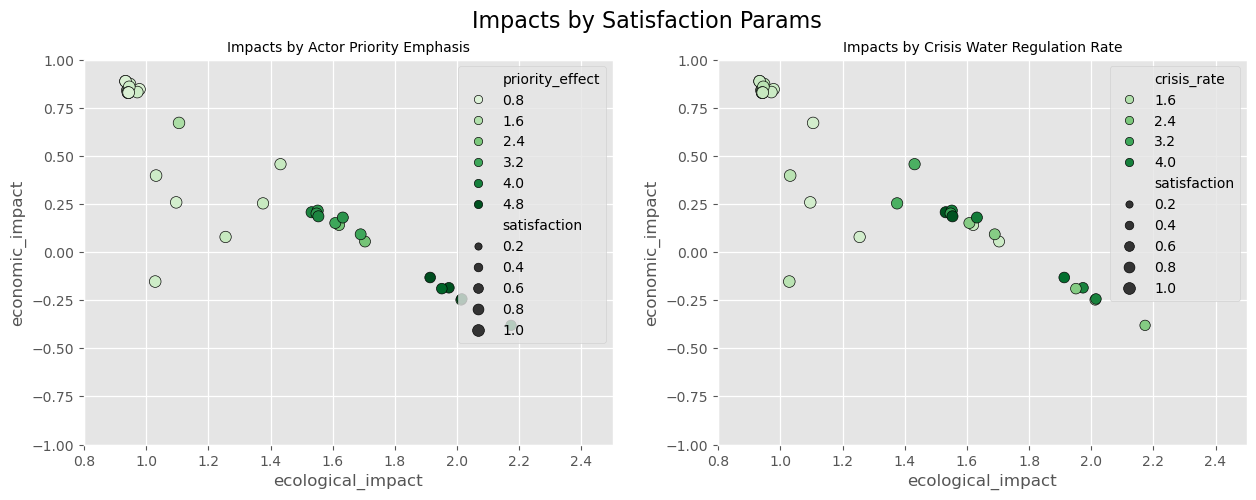

In [38]:
fig, ax = plt.subplots(1, 2, figsize = (15, 5))
sns.scatterplot(combined_df, x = 'ecological_impact', y = 'economic_impact', hue = 'priority_effect', ax = ax[0], hue_norm = (0, 5),  edgecolor = 'black',palette =  'Greens', size = 'satisfaction')
sns.scatterplot(combined_df, x = 'ecological_impact', y = 'economic_impact', hue = 'crisis_rate', ax = ax[1], hue_norm = (0, 5), edgecolor = 'black', palette = 'Greens', size = 'satisfaction')
ax[0].set_ylim(-1, 1)
ax[0].set_xlim(0.8, 2.5)
ax[0].set_title('Impacts by Actor Priority Emphasis', fontsize = 10)
ax[1].set_ylim(-1, 1)
ax[1].set_xlim(0.8, 2.5)
ax[1].set_title('Impacts by Crisis Water Regulation Rate', fontsize = 10)
fig.suptitle('Impacts by Satisfaction Params', fontsize = 16);
plt.savefig('./assets/images/impacts_by_satisfaction_params.png', dpi = 300, bbox_inches = 'tight')

### Fine and Subsidy Interaction
Fine and subsidy interaction

<Axes: xlabel='max_subvention_weight', ylabel='max_fine_weight'>

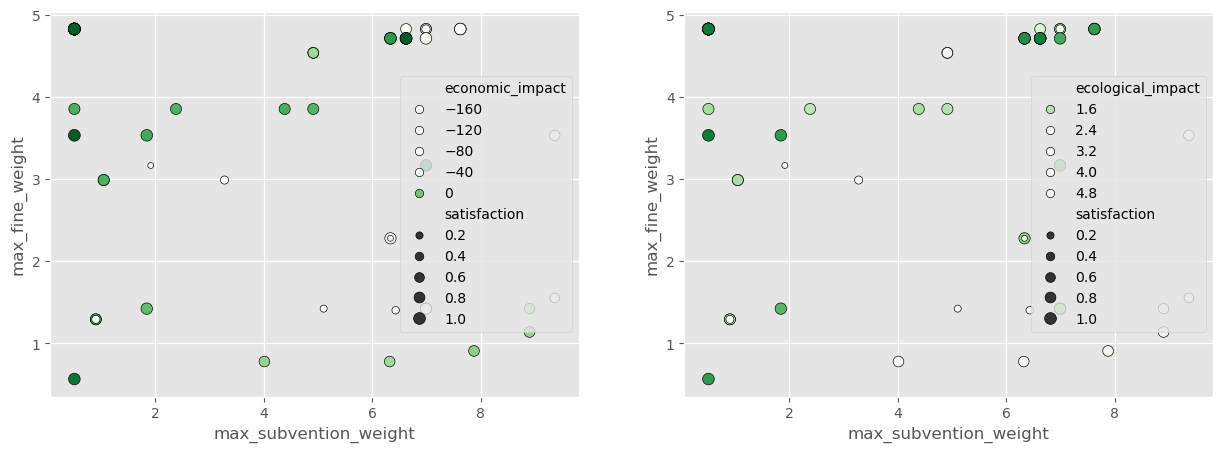

In [33]:
fig, ax = plt.subplots(1, 2, figsize = (15, 5))
sns.scatterplot(combined_df, x = 'max_subvention_weight', y = 'max_fine_weight', hue = 'economic_impact', edgecolor = 'black', ax = ax[0], hue_norm = (-1, 1), size = 'satisfaction', palette =  'Greens')
sns.scatterplot(combined_df, x = 'max_subvention_weight', y = 'max_fine_weight', hue = 'ecological_impact', edgecolor = 'black', ax = ax[1], hue_norm = (0.7, 2), palette = 'Greens_r', size = 'satisfaction')

### Objectives and Parameters Distribution by Satisfaction
- When satisfaction is achieved, cooperation levels tend to stabilize around a compact distribution—typically centered near 0.5
- indicating a balanced and cohesive system. However, in scenarios where satisfaction is low, cooperation becomes more diffuse and variable.
- This pattern suggests that dissatisfaction leads to fragmentation in cooperative behavior, potentially destabilizing system dynamics.  
    

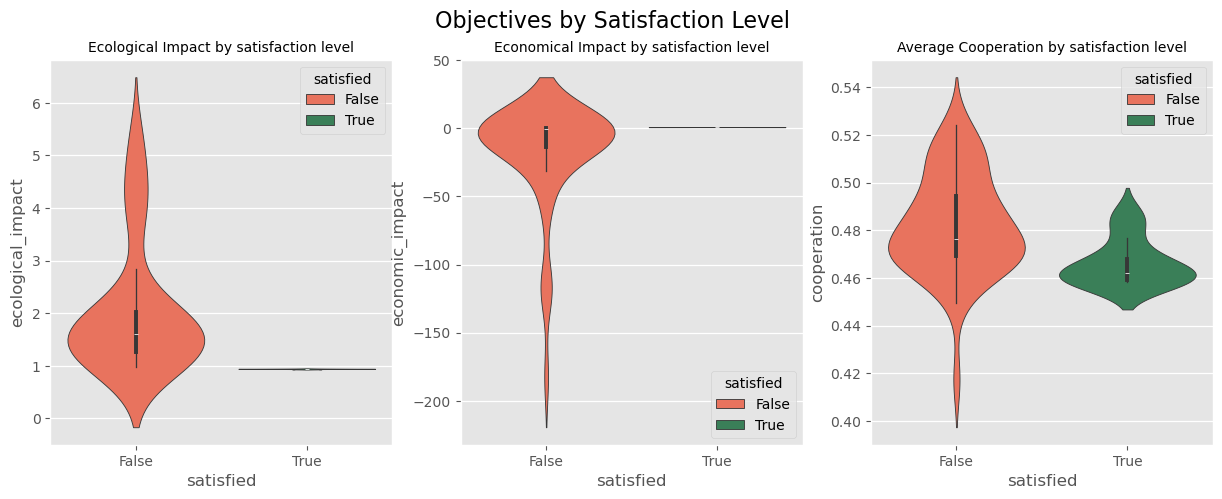

In [42]:
fig, ax = plt.subplots(1, 3)
sns.violinplot(combined_df, x = 'satisfied', y = 'ecological_impact', hue = 'satisfied', ax = ax[0], palette = priority_ok)
ax[0].set_title('Ecological Impact by satisfaction level', fontsize = 10)
sns.violinplot(combined_df, x = 'satisfied', y = 'economic_impact', hue = 'satisfied', ax = ax[1], palette = priority_ok)
ax[1].set_title('Economical Impact by satisfaction level', fontsize = 10)
sns.violinplot(combined_df, x = 'satisfied', y = 'cooperation', hue = 'satisfied', ax = ax[2], palette = priority_ok)
ax[2].set_title('Average Cooperation by satisfaction level', fontsize = 10)
fig.suptitle('Objectives by Satisfaction Level', fontsize = 16);
plt.savefig('./assets/images/objectives by satisfaction.png', bbox_inches = 'tight')

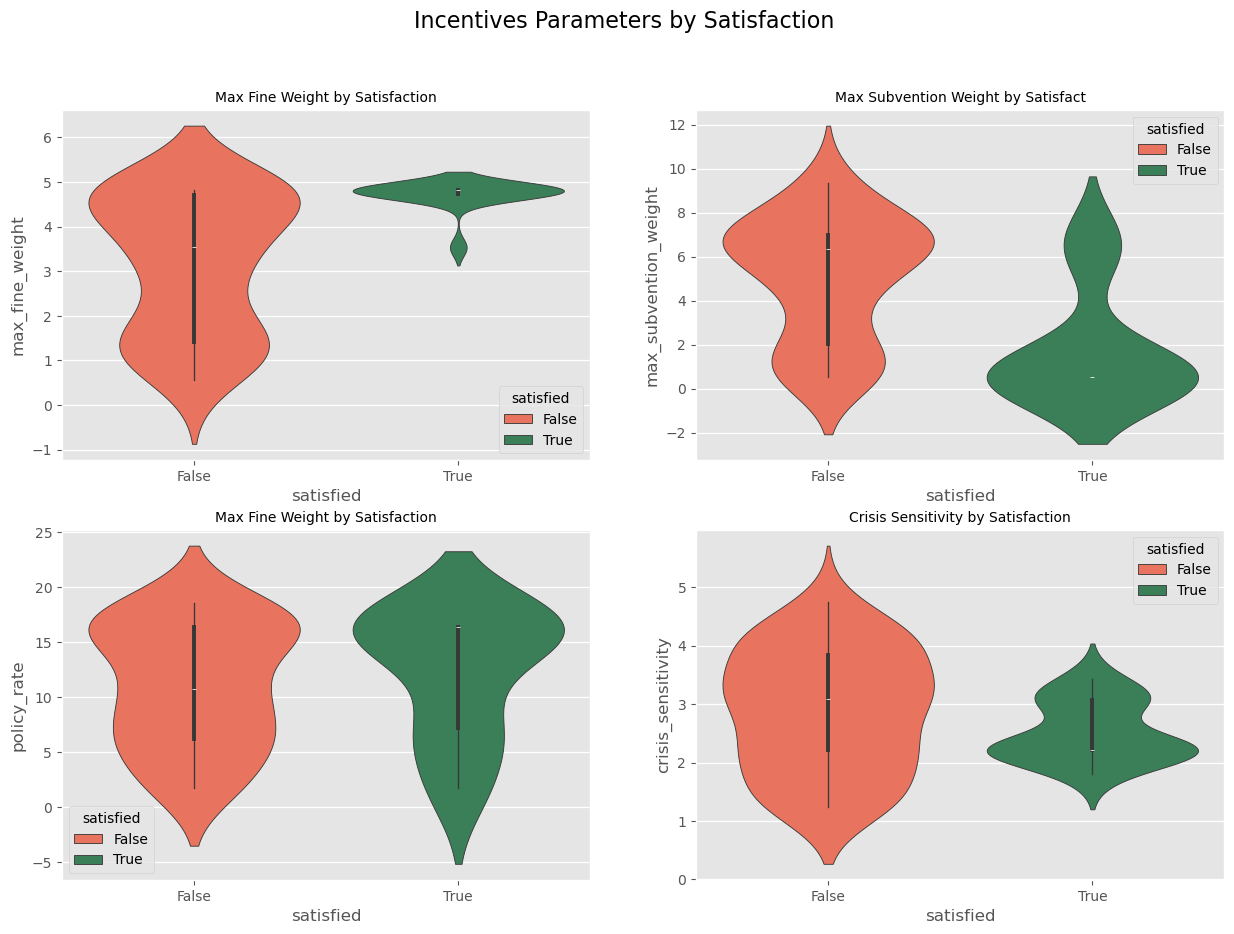

In [43]:
fig, ax = plt.subplots(2, 2, figsize = (15, 10))
ax = ax.flatten()
sns.violinplot(combined_df, x = 'satisfied', y = 'max_fine_weight', hue = 'satisfied', ax = ax[0], palette = priority_ok)
ax[0].set_title('Max Fine Weight by Satisfaction', fontsize = 10)
sns.violinplot(combined_df, x = 'satisfied', y = 'max_subvention_weight', hue = 'satisfied', ax = ax[1], palette = priority_ok)
ax[1].set_title('Max Subvention Weight by Satisfact', fontsize = 10)
sns.violinplot(combined_df, x = 'satisfied', y = 'policy_rate', hue = 'satisfied', ax = ax[2], palette = priority_ok)
ax[2].set_title('Max Fine Weight by Satisfaction', fontsize = 10)
sns.violinplot(combined_df, x = 'satisfied', y = 'crisis_sensitivity', hue = 'satisfied', ax = ax[3], palette = priority_ok)
ax[3].set_title('Crisis Sensitivity by Satisfaction', fontsize = 10)
fig.suptitle('Incentives Parameters by Satisfaction', fontsize = 16);
plt.savefig('./assets/images/incentives params by satisfaction.png', bbox_inches = 'tight')

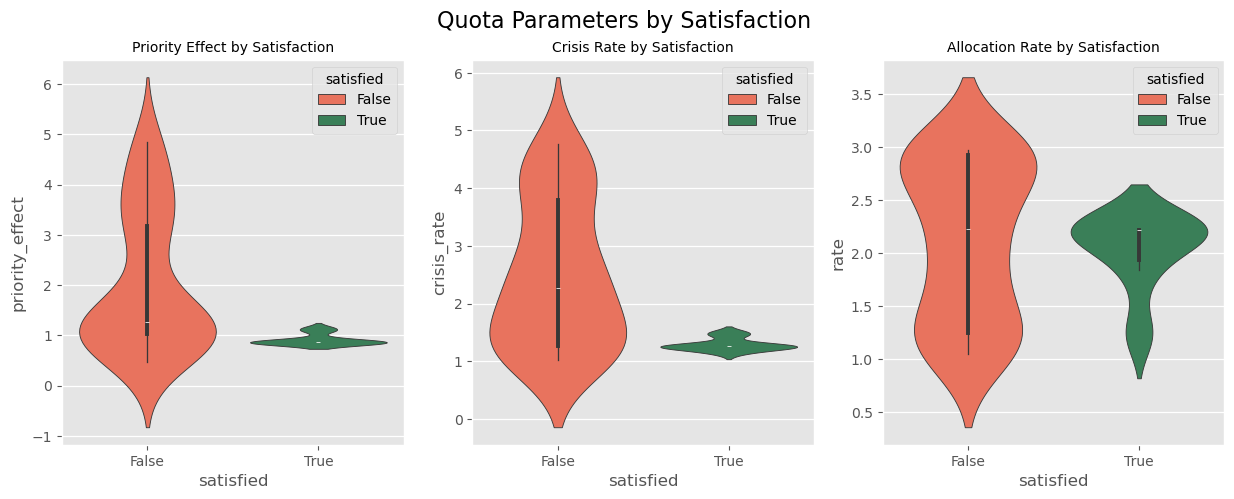

In [41]:
fig, ax = plt.subplots(1, 3)
sns.violinplot(combined_df, x = 'satisfied', y = 'priority_effect', hue = 'satisfied', ax = ax[0], palette = priority_ok)
ax[0].set_title('Priority Effect by Satisfaction', fontsize = 10)
sns.violinplot(combined_df, x = 'satisfied', y = 'crisis_rate', hue = 'satisfied', ax = ax[1], palette = priority_ok)
ax[1].set_title('Crisis Rate by Satisfaction', fontsize = 10)
sns.violinplot(combined_df, x = 'satisfied', y = 'rate', hue = 'satisfied', ax = ax[2], palette = priority_ok)
ax[2].set_title('Allocation Rate by Satisfaction', fontsize = 10)
fig.suptitle('Quota Parameters by Satisfaction', fontsize = 16);
plt.savefig('./assets/images/quota params by satisfaction.png', dpi = 300, bbox_inches = 'tight')